In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
# import pygraphviz as pgv
import array
import random
import operator
import time

from deap import base
from deap import creator
from deap import tools
from deap import gp

Fix constants. We want a big population since a lot of them will have errors, either mathematical (0/0, inf-inf, log(-a)...) or computational. We also want a lot of mutation because trees will be small (at least in the beginning) and mutations can be insignificant in some cases (change equal terminals, change the order of conmutative operations...).

In [19]:
MUTATION_RATE = 0.1
CROSSOVER_RATE = 0.7
POPULATION_SIZE = 200
ELITISM = 5
VARIETY = 2*ELITISM

MAX_GENERATIONS = 50
LAG = 5

min_init_depth = 2
max_init_depth = 4
max_allowed_depth = 10
toolbox = base.Toolbox()

#random.seed(1)

As usual, we want some bad practices so we ignore all warnings. These are runtime warnings from overflows, divisions by 0, infinities...

In [3]:
import warnings
warnings.filterwarnings('ignore')  # Suppress all warnings

# Pset


Define safe operations

In [20]:
def safe_div(a,b):
    if b == a:
        return 1
    if b == 0:
        return np.inf
    return a/b

def safe_log(a):
    if a == 0:
        return np.inf
    return np.log(float(abs(a)))

def safe_round(a):
    if abs(a) == np.inf:
        return a
    return round(a)

#def safe_pow(a,b):
#    # no complex numbers
#    if a < 0 and (int(b)-b!=0):
#        result = (-a)**b
#        return result
#    return a**b

Define how constants are generated

In [21]:
def efimeros():
    p = random.random()
    threshold = 0.1 # for constants
    constants = [np.pi,np.e]
    num = len(constants)
    if p<1-threshold:
        return round(random.uniform(-10, 10),1)
    for i in range(num):
        if p<1-threshold*(num-i-1)/num:
            return constants[i]

And add all primitives (functions) to pset

In [22]:
pset = gp.PrimitiveSet("MAIN", 1)
pset.renameArguments(ARG0="x")

pset.addPrimitive(operator.add, 2)
pset.addPrimitive(operator.mul, 2)
pset.addPrimitive(safe_div, 2)
#pset.addPrimitive(safe_pow, 2)
pset.addPrimitive(safe_log, 1)
pset.addPrimitive(safe_round, 1)
pset.addEphemeralConstant("num",efimeros)

# Other deap things

Define evaluation function

In [23]:
def calc_fitness(ind):
    f = toolbox.compile(expr=ind)
    try:
        y_ = np.array([f(x_) for x_ in x])
        #fit = np.mean(np.abs(y_ - y)) # mean error
        fit = np.mean((y_ - y)**2) # mean squared error
        if np.isnan(fit) or fit < 0: # sometimes fit is negative for some reason and i don't know why
            ind.fitness.values = tuple([np.inf])
            return tuple([np.inf])

    except Exception:
        ind.fitness.values = tuple([np.inf])
        return tuple([np.inf])
    ind.fitness.values =  tuple([fit])
    return tuple([fit])

We also define how we want to mutate individuals. We want to change them and sometimes shrink them to avoid huge trees.

When the resulting tree is over the height limit we try again to get a possibly smaller tree. Due to the high probability of shrinking this process will end up giving an acceptable tree at some point.

In [24]:
def random_mutation(ind):
    aux = 1
    while ind.height > max_allowed_depth or aux:
        aux = 0
        if random.random() < 0.6:
            # at least 1 change, more changes for bigger trees depending on MUTATION_RATE
            changes = int(1+MUTATION_RATE*len(ind)*abs(random.gauss(0,1)))
            for i in range(changes):
                ind = gp.mutNodeReplacement(ind,pset)[0]
        else:
            gp.mutShrink(ind)

toolbox.register("mutate", random_mutation)

We also define crossover to avoid the same problem with big trees. If a tree is too big we (randomly) shrink it until it's not

In [25]:
def crossover(ind1,ind2):
    # actual crossover
    gp.cxOnePoint(ind1, ind2)

    while ind1.height > max_allowed_depth:
            gp.mutShrink(ind1)
    while ind2.height > max_allowed_depth:
            gp.mutShrink(ind2)

toolbox.register("mate", crossover)


# this is also supposed to avoid going over the max depth, but thats an illusion by the elites to maintain an status quo where they keep power and make the working class think they could at some point escape from their lives and attain vital acomplishment or freedom
#toolbox.decorate("mate", gp.staticLimit(key=operator.attrgetter('height'), max_value=max_allowed_depth))


Now register all needed operations in the toolbox

In [26]:
toolbox.register("compile", gp.compile, pset=pset)
creator.create("FitnessMin", base.Fitness, weights=(-1.0,)) # we want the minimum error
creator.create("Individual", gp.PrimitiveTree,fitness=creator.FitnessMin, prim_set=pset) # "type" of individual
toolbox.register("expr", gp.genHalfAndHalf,pset=pset, min_=min_init_depth, max_=max_init_depth) # how we generate
toolbox.register("individual", tools.initIterate,container=creator.Individual,generator=toolbox.expr) # individual generator
toolbox.register("population", tools.initRepeat, list, toolbox.individual)

# selection methods
toolbox.register("select", tools.selTournament, tournsize=5)
# toolbox.register("select", tools.selBest, k=int(POPULATION_SIZE/10))


# Evolution

Create initial population. We define the population to be a fixed number of very small trees. We also evaluate for the first time so that we can create a hall of fame for the best individuals.

In [27]:
def create_population():
    hof = tools.HallOfFame(10)
    popu = toolbox.population(n=POPULATION_SIZE)
    fit = list(map(calc_fitness, popu)) # fit isn't really needed as a variable, but if we don't save somewhere the interpreter omits the map
    hof.update(popu)
    return hof,popu

We evolve it up to a number of generation or if we stop improving for a few generations. The strategy is the following:
- Select some of the original population through tournament (copying them)
- Mutate and crossover this selection to create offspring
- Keep some of the best from the previous generation, the offspring and some new and random individuals to encourage diversity

Every generation updates the hall of fame. It is close to redundant, but because it avoids repeating the best and keeps some best results possible lost by elitism we still do it.

In [28]:
def evolve(hof,popu):
    best=[]
    g = 0

    # We need some generations to compare for improvement
    for i in range(LAG):
        g += 1
        print(f"Gen {g}: ", end='')
        offspring = toolbox.select(popu, POPULATION_SIZE-ELITISM-VARIETY)
        # Clone the selected individuals
        offspring = list(map(toolbox.clone, offspring))

        # crossover and mutate
        for child1, child2 in zip(offspring[::2], offspring[1::2]):
            if random.random() < CROSSOVER_RATE:
                toolbox.mate(child1, child2)
                del child1.fitness.values
                del child2.fitness.values

        for mutant in offspring:
            if random.random() < MUTATION_RATE:
                toolbox.mutate(mutant)
                del mutant.fitness.values
        # new population = best of last gen, offspring and new people
        popu = tools.selBest(popu,ELITISM)+offspring+toolbox.population(n=VARIETY)

        fit = list(map(calc_fitness, popu))
        best.append(min(fit)[0])
        hof.update(popu)

        print(best[-1])

    # repeat
    while g < MAX_GENERATIONS and best[-1] != best[-LAG]:
        g += 1
        print(f"Gen {g}: ", end='')
        offspring = toolbox.select(popu, POPULATION_SIZE-ELITISM-VARIETY)
        offspring = list(map(toolbox.clone, offspring))

        for child1, child2 in zip(offspring[::2], offspring[1::2]):
            if random.random() < CROSSOVER_RATE:
                toolbox.mate(child1, child2)
                del child1.fitness.values
                del child2.fitness.values

        for mutant in offspring:
            if random.random() < MUTATION_RATE:
                toolbox.mutate(mutant)
                del mutant.fitness.values
        popu = tools.selBest(popu,ELITISM)+offspring+toolbox.population(n=VARIETY)

        fit = list(map(calc_fitness, popu))
        best.append(min(fit)[0])
        hof.update(popu)

        print(best[-1])
    return best

# Run and analyze

In [29]:
t1 = time.time()
data = pd.read_csv('pi.csv', header=None)

x = data.iloc[1:,0].values
y = data.iloc[1:,1].values

hof1, popu1 = create_population()
best1 = evolve(hof1,popu1)
t2 = time.time()
print(f"time elapsed: {round(t2-t1,2)}s")

Gen 1: 7728.3668169099465
Gen 2: 2295.8900969345477
Gen 3: 2295.8900969345477
Gen 4: 2295.8900969345477
Gen 5: 2293.0476016313805
Gen 6: 125.88750899856409
Gen 7: 125.88750899856409
Gen 8: 124.78606030489755
Gen 9: 10.342231371883171
Gen 10: 9.169907662090813
Gen 11: 9.169907662090813
Gen 12: 9.169907662090813
Gen 13: 5.308329169667297
Gen 14: 5.308329169667297
Gen 15: 5.308329169667297
Gen 16: 5.308329169667297
Gen 17: 5.308329169667297
time elapsed: 250.22s


safe_div(add(safe_div(safe_round(x), safe_log(add(safe_div(add(safe_div(x, safe_log(safe_div(x, 4.8))), safe_round(x)), 4.8), safe_log(x)))), x), safe_log(x))


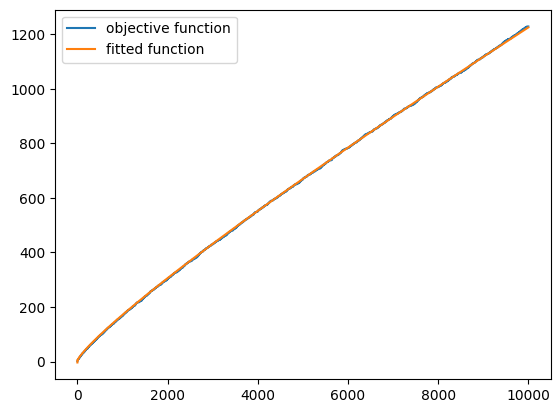

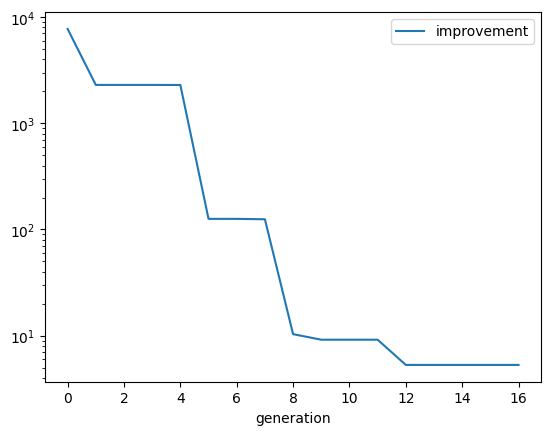

In [30]:
ind = hof1[0]
print(ind)
f = toolbox.compile(ind)

plt.plot(x, y, label='objective function')
plt.plot(x, [f(i) for i in x], label='fitted function')
plt.legend()
plt.show()

plt.semilogy(best1, label='improvement')
plt.xlabel("generation")
plt.legend()
plt.show()

In [15]:
t1 = time.time()
data = pd.read_csv('eul.csv', header=None)

x = data.iloc[1:,0].values
y = data.iloc[1:,1].values

hof2, popu2 = create_population()
best2 = evolve(hof2,popu2)
t2 = time.time()
print(f"time elapsed: {round(t2-t1,2)}s")

Gen 1: 4395318.260095944
Gen 2: 4395318.260095944
Gen 3: 4387171.970928497
Gen 4: 4387171.970928497
Gen 5: 4387171.970928497
Gen 6: 4387171.970928497
Gen 7: 4387171.970928497
time elapsed: 121.78s


safe_div(mul(-5.2, safe_round(x)), -8.5)


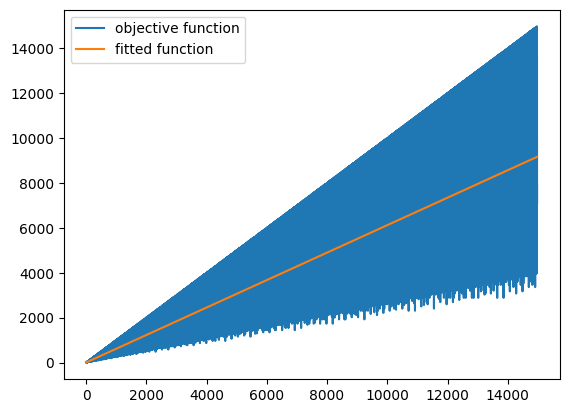

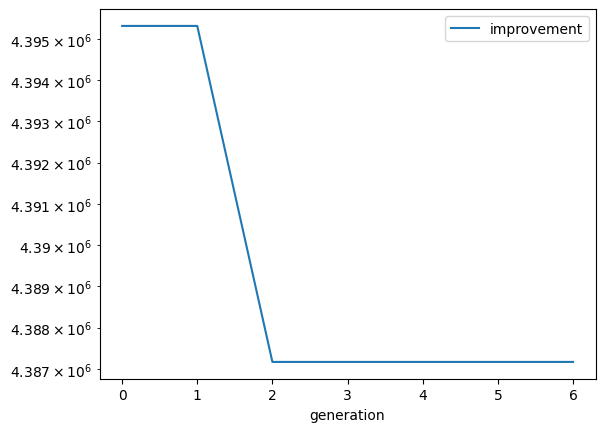

In [17]:
ind = hof2[0]
print(ind)
f = toolbox.compile(ind)

plt.plot(x, y, label='objective function')
plt.plot(x, [f(i) for i in x], label='fitted function')
plt.legend()
plt.show()

plt.semilogy(best2, label='improvement')
plt.xlabel("generation")
plt.legend()
plt.show()

# Conclusions

The pi function is much better approximated than the euler totient function.

We also notice that the improvement is janky and spontaneous instead of smooth, implying that thongs improve when we get a "correct" characteristic. If we were to expand the population size, we would have a much faster convergence since the correct characteristic would appear earlier.

## Pi function
We know from Gauss and Legendre that the pi function grows as $\pi(x)≈\frac{x}{log(x)}$. Our best approximations were consistent with this, showing (in a very redundant way) a formula close to $\pi(x)≈\frac{x+o(x)}{log(x)}$ (using little o notation).

Even though we didn't have a training dataset and a evaluation dataset, since the function can be expressed as continuous almost everywhere and is also monotonic, we have reason to believe it would not be particularly beneficial in terms of avioding overfitting or the predicting power of the result.

The best resultwas something of the form $\frac{x+\frac{x}{log(\frac{x}{4.5}+160)}}{log(x)}$

3.6742614212584153


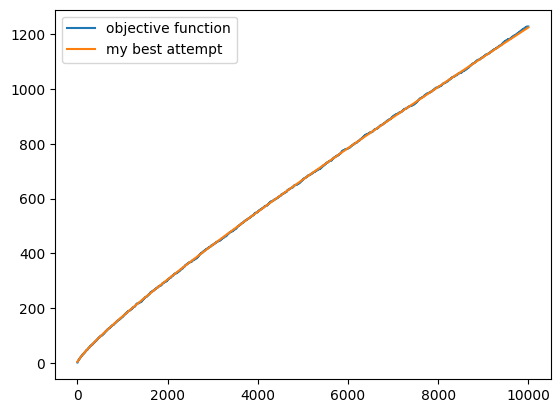

In [111]:
def correct_pi(x):
    return((x/(safe_log(x/4.5+160))+x)/safe_log(x))

data = pd.read_csv('pi.csv', header=None)

x = data.iloc[1:,0].values
y = data.iloc[1:,1].values

y_ = np.array([correct_pi(x_) for x_ in x])
fit = np.mean((y_ - y)**2)
print(fit)

plt.plot(x, y, label='objective function')
plt.plot(x, [correct_pi(i) for i in x], label='my best attempt')
plt.legend()
plt.show()

## Euler's Totient function
Regarding the totient function, nothing works. It's more or less lineal except it's almost a cone. This means that the error is huge and, since the appearence of primes is unpredictable, it will have no predicting capabilities. Our best approximation tends to be of the form $\phi(x)\approx c_0x$